In [1]:
import run as run
import chephy_model as cpm
import GNN_model
import gnn_utils
import numpy as np
import torch
import pandas as pd
from torch_geometric.transforms import ToUndirected


/home/dsi/chenbis/anaconda3/envs/chephy2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def create_hetero_data(data, label_header, cdr3_header, atchley_dict, n=1000, distance_threshold = 0.2, use_mst=True, enrich=False):

    data = data.sample(n=n, random_state=42)

    data = run.prepare_data(data, cdr3_header, label_header)    
    data = cpm.truncate_sequences(data, cdr3_header, 4, 4)

    sequences = set(data["cdr3_truncated"])
    epitopes = list(set(data[label_header]))

    chephy_matrix, sequences_list = cpm.find_che_phy_dist(sequences)
    sequence_indices = np.arange(len(sequences_list))

    data['tcr_index'] = data['cdr3_truncated'].apply(lambda x: sequences_list.index(x) if x in sequences_list else -1)
    data['epitope_index'] = data[label_header].apply(lambda x: epitopes.index(x) if x in epitopes else -1)

    data_hetero, labels = gnn_utils.build_hetero_graph(
                            data,
                            chephy_matrix,
                            sequences_list,
                            epitopes,
                            atchley_dict,
                            distance_threshold=distance_threshold,
                            use_mst=use_mst,
                            enrich=enrich  
                        )
    data_hetero = ToUndirected()(data_hetero)
    return data_hetero, data


In [3]:
label_header = "peptide"
cdr3_header = "cdr3"

In [4]:
atchley_path = "/home/dsi/chenbis/repos/sol_lab/files/atchley.csv"
atchley_df = pd.read_csv(atchley_path)
atchley_dict = atchley_df.set_index("amino.acid").to_dict(orient="index")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
from sklearn.model_selection import train_test_split

train_file = "/home/dsi/chenbis/repos/sol_lab/data/train.tsv"
test_file  = "/home/dsi/chenbis/repos/sol_lab/data/test.tsv"

train_df = run.load_dataframe(train_file)
test_df  = run.load_dataframe(test_file)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["Binding"],
    random_state=42
)

In [6]:
def get_graphs(distance_threshold, use_mst, enrich):
    train_graph, train_data = create_hetero_data(
        train_df,
        label_header,
        cdr3_header,
        atchley_dict,
        n=48000,
        distance_threshold=distance_threshold,
        use_mst=use_mst,
        enrich=enrich
    )

    val_graph, val_data = create_hetero_data(
        val_df,
        label_header,
        cdr3_header,
        atchley_dict,
        n=len(val_df),
        distance_threshold=distance_threshold,
        use_mst=use_mst,
        enrich=enrich
    )

    test_graph, test_data = create_hetero_data(
        test_df,
        label_header,
        cdr3_header,
        atchley_dict,
        n=15000,
        distance_threshold=distance_threshold,
        use_mst=use_mst,
        enrich=enrich
    )

    return train_graph, train_data, val_graph, val_data, test_graph, test_data
    

In [7]:
def create_edge_labels(df):

    edge_pairs = df[['tcr_index','epitope_index']].values

    edge_index = torch.tensor(edge_pairs.T)

    y = df["Binding"].values

    return edge_index, y

In [8]:
def train_one_model(train_graph, val_graph, train_edge_index, val_edge_index,
        y_train,
        y_val):

    model = GNN_model.HeteroTCR(train_graph.metadata(), 256, 3, "SAGE").to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=0.0)

    # Track performance
    epoch = []
    loss = []
    acc = []
    auc_roc = []
    val_loss = []
    val_acc = []
    val_auc_roc = []

    # Best model tracking
    best_val_auc = -float('inf')
    best_val_loss = float('inf')
    best_auc_model_state = None
    best_loss_model_state = None
    best_auc_epoch = 0
    best_loss_epoch = 0

    best_auc = -1

    best_state = None

    history = []

    for epoch in range(1000):

        train_loss, train_acc, train_auc, val_loss, val_acc, val_auc = GNN_model.train(
            model, optimizer,
            train_graph, val_graph,
            train_edge_index, val_edge_index,
            y_train, y_val,
            device
        )

        history.append([
            epoch,
            train_loss.item(),
            train_auc.item(),
            val_loss.item(),
            val_auc.item()
        ])

        if val_auc > best_auc:

            best_auc = val_auc
            best_state = model.state_dict()

    model.load_state_dict(best_state)

    return model, history, best_auc

In [9]:
def evaluate_model(
        model,
        test_graph,
        test_edge_index,
        y_test):

    test_loss,\
    test_acc,\
    test_auc,\
    test_prob = GNN_model.predict(
        model,
        test_graph,
        test_edge_index,
        y_test
    )

    return test_auc, test_prob

In [10]:
thresholds = lst = [i / 100 for i in range(101)]
configs = []
configs.append((True, False, 0.0))
for threshold in thresholds:
    configs.append((True, True, threshold))
    configs.append((False, True, threshold))
configs.remove((False, True, 0.0))
configs.remove((True, True, 0.0))
seeds = [0,1,2,3,4]

In [11]:
configs = configs[:21]

In [12]:
results = pd.read_csv("output/results/hyperparameter_results2 copy.csv")

In [13]:
from scipy.stats import wilcoxon

best_cfg = (True, True, 0.08)

models = []
pvalues = []

best = results[
    (results.mst == best_cfg[0]) &
    (results.enrich == best_cfg[1]) &
    (results.threshold == best_cfg[2])
].sort_values("seed")["validation_auc"]

for mst, enrich, thr in configs:

    if (mst, enrich, thr) == best_cfg:
        continue

    current = results[
        (results.mst == mst) &
        (results.enrich == enrich) &
        (results.threshold == thr)
    ].sort_values("seed")["validation_auc"]

    stat, p = wilcoxon(best, current)

    models.append((mst, enrich, thr))
    pvalues.append(p)

In [14]:
from statsmodels.stats.multitest import multipletests

reject,p_corrected,_,_ = multipletests(

    pvalues,

    method="holm"

)

for m,p,pc,r in zip(models,pvalues,p_corrected,reject):

    print(m)

    print("raw =",p)

    print("holm =",pc)

    print("significant =",r)

(True, False, 0.0)
raw = 0.0625
holm = 1.0
significant = False
(True, True, 0.01)
raw = 0.0625
holm = 1.0
significant = False
(False, True, 0.01)
raw = 0.0625
holm = 1.0
significant = False
(True, True, 0.02)
raw = 0.0625
holm = 1.0
significant = False
(False, True, 0.02)
raw = 0.0625
holm = 1.0
significant = False
(True, True, 0.03)
raw = 0.0625
holm = 1.0
significant = False
(False, True, 0.03)
raw = 0.0625
holm = 1.0
significant = False
(True, True, 0.04)
raw = 0.0625
holm = 1.0
significant = False
(False, True, 0.04)
raw = 0.0625
holm = 1.0
significant = False
(True, True, 0.05)
raw = 0.0625
holm = 1.0
significant = False
(False, True, 0.05)
raw = 0.0625
holm = 1.0
significant = False
(True, True, 0.06)
raw = 0.0625
holm = 1.0
significant = False
(False, True, 0.06)
raw = 0.0625
holm = 1.0
significant = False
(True, True, 0.07)
raw = 0.0625
holm = 1.0
significant = False
(False, True, 0.07)
raw = 0.0625
holm = 1.0
significant = False
(False, True, 0.08)
raw = 0.0625
holm = 1.0
sign

In [15]:
labels = [
    f"normalize={m[0]}\nweighted={m[1]}\nth={m[2]}"
    for m in models
]

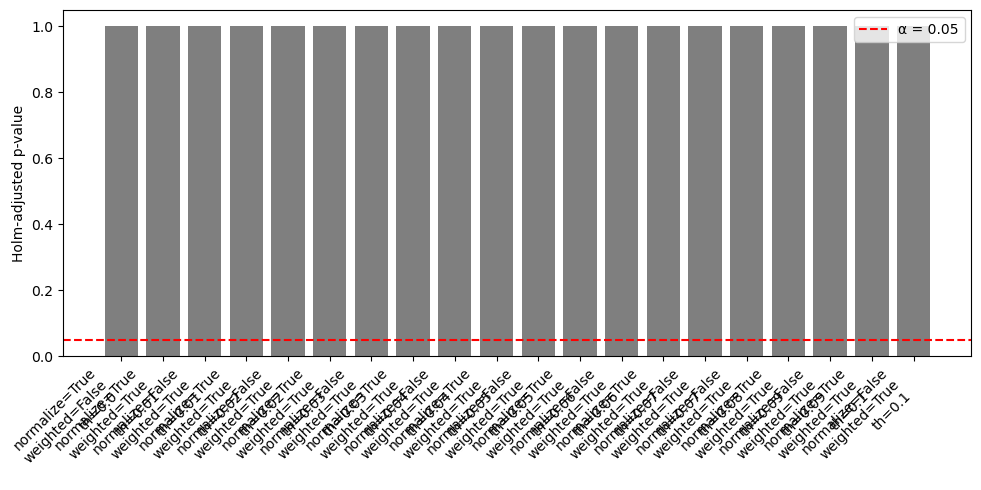

In [16]:
import matplotlib.pyplot as plt
import numpy as np

colors = ["tab:red" if r else "tab:gray" for r in reject]

plt.figure(figsize=(10,5))

plt.bar(labels, p_corrected, color=colors)

plt.axhline(
    0.05,
    color="red",
    linestyle="--",
    label="α = 0.05"
)

plt.ylabel("Holm-adjusted p-value")
plt.xticks(rotation=45, ha="right")
plt.legend()

plt.tight_layout()
plt.show()

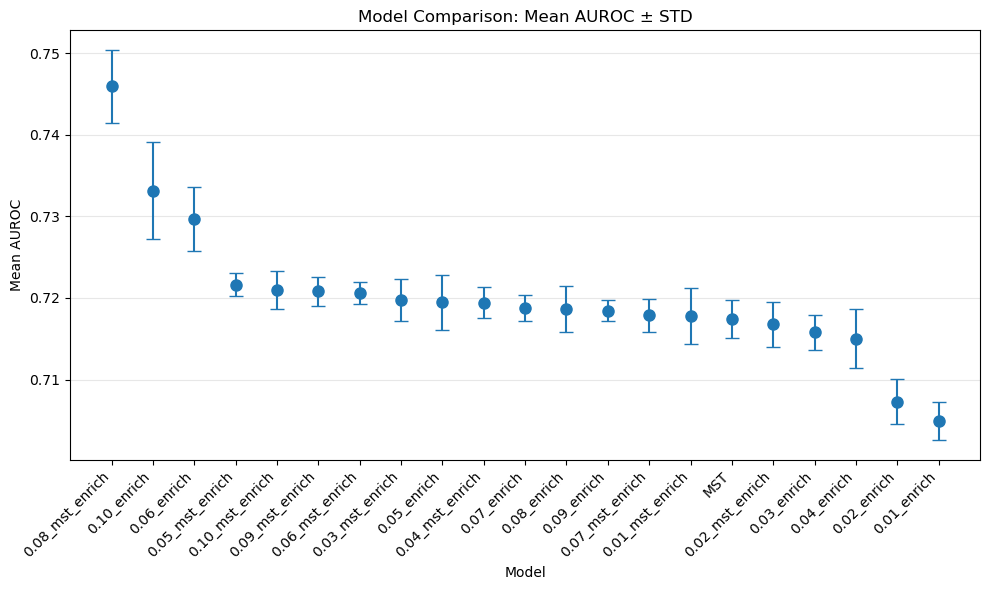

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# Load results
# -----------------------
df = pd.read_csv("output/results/hyperparameter_results2 copy.csv")

# -----------------------
# Create model names
# -----------------------
def model_name(row):
    if row["mst"] and not row["enrich"]:
        return "MST"

    if row["mst"] and row["enrich"]:
        return f"{row['threshold']:.2f}_mst_enrich"

    if (not row["mst"]) and row["enrich"]:
        return f"{row['threshold']:.2f}_enrich"

    return "Full"

df["Model"] = df.apply(model_name, axis=1)

# -----------------------
# Mean ± STD
# -----------------------
summary = (
    df.groupby("Model")
      .agg(
          mean_auc=("validation_auc", "mean"),
          std_auc=("validation_auc", "std")
      )
      .sort_values("mean_auc", ascending=False)
      .reset_index()
)

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(10,6))

plt.errorbar(
    summary["Model"],
    summary["mean_auc"],
    yerr=summary["std_auc"],
    fmt='o',
    capsize=5,
    markersize=8,
    linewidth=1.5
)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Mean AUROC")
plt.xlabel("Model")

plt.title("Model Comparison: Mean AUROC ± STD")

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig("validation_auroc.png", dpi=300)

plt.show()

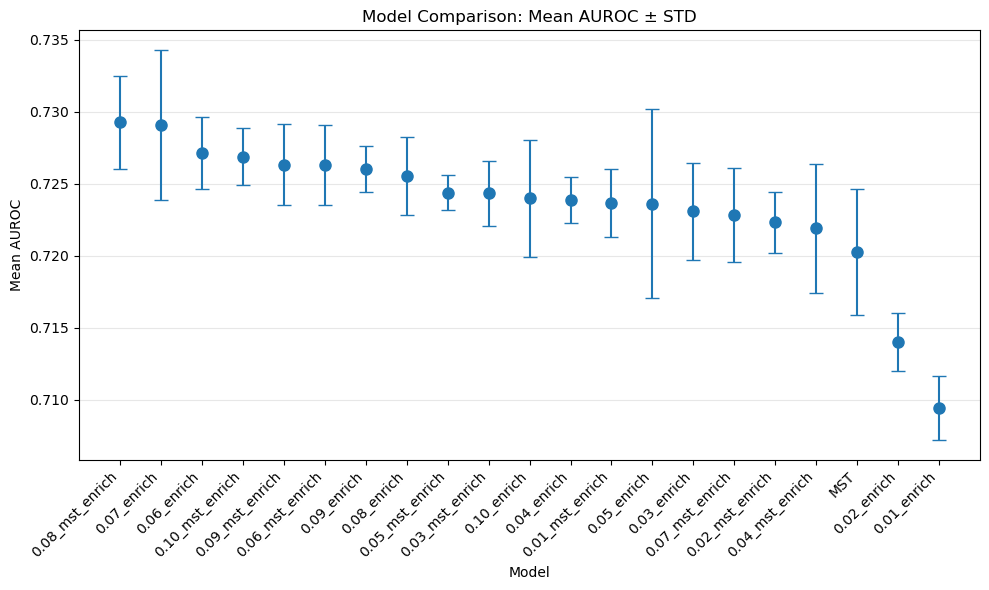

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# Load results
# -----------------------
df = pd.read_csv("output/results/hyperparameter_results2 copy.csv")

# -----------------------
# Create model names
# -----------------------
def model_name(row):
    if row["mst"] and not row["enrich"]:
        return "MST"

    if row["mst"] and row["enrich"]:
        return f"{row['threshold']:.2f}_mst_enrich"

    if (not row["mst"]) and row["enrich"]:
        return f"{row['threshold']:.2f}_enrich"

    return "Full"

df["Model"] = df.apply(model_name, axis=1)

# -----------------------
# Mean ± STD
# -----------------------
summary = (
    df.groupby("Model")
      .agg(
          mean_auc=("test_auc", "mean"),
          std_auc=("test_auc", "std")
      )
      .sort_values("mean_auc", ascending=False)
      .reset_index()
)

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(10,6))

plt.errorbar(
    summary["Model"],
    summary["mean_auc"],
    yerr=summary["std_auc"],
    fmt='o',
    capsize=5,
    markersize=8,
    linewidth=1.5
)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Mean AUROC")
plt.xlabel("Model")

plt.title("Model Comparison: Mean AUROC ± STD")

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig("validation_auroc.png", dpi=300)

plt.show()